<a href="https://colab.research.google.com/github/harubaru/dalle2-laion/blob/main/dalle2_laion_alpha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Acknowledgements

First, a huge thank you to [LucidRains](https://github.com/lucidrains) for his amazing work creating dalle2 model repo.

Thank you to [Nousr](https://twitter.com/nousr_) and [Aidan](https://github.com/Veldrovive) for their work on the training scripts for the prior and decoder. As well, thank you to [Romain](https://github.com/rom1504) for his role in the creation of dataset used as well as providing advice and support.

This was trained thanks to the generous donation of compute time from [LAION](https://laion.ai/) and its sponsors, especially [StabilityAI](https://stability.ai/) for the servers used in this project.
This model was trained using the aesthetic subset of the [LAION2B dataset](https://laion.ai/blog/laion-5b/), details of the run can be found on [wandb](https://wandb.ai/nousr_laion/dalle2_train_decoder/reports/Decoder-Training--VmlldzoyMjEyMjcw).

#### This is a WIP notebook.
It is missing the upsamplers so it can only produce 64x64 images and has only be trained for 0.5% of what OpenAI did for their DALLE2. It can still produce some impressive results, but is not nearly at the level you might see on the news yet.

In [1]:
!nvidia-smi

Sun Jul 10 00:10:45 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   63C    P8    11W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

### Setup

In [3]:
#@title
# I would suggest running on a remote machine https://research.google.com/colaboratory/local-runtimes.html

# !pip install dalle2_pytorch==0.11.4
!pip install git+https://github.com/Veldrovive/DALLE2-pytorch@f4b687798d367fc434d8127ab31141f0fea0db26
!pip install wandb
!pip install ipywidgets
!pip install matplotlib

import wandb
import torch
import os
import importlib
import ipywidgets as widgets


from dalle2_pytorch import DALLE2, DiffusionPriorNetwork, DiffusionPrior, OpenAIClipAdapter, train_configs
from dalle2_pytorch.tokenizer import tokenizer

import matplotlib.pyplot as plt
import numpy as np


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/Veldrovive/DALLE2-pytorch (to revision f4b687798d367fc434d8127ab31141f0fea0db26) to /tmp/pip-req-build-ch23e06p
  Running command git clone -q https://github.com/Veldrovive/DALLE2-pytorch /tmp/pip-req-build-ch23e06p
  Running command git rev-parse -q --verify 'sha^f4b687798d367fc434d8127ab31141f0fea0db26'
  Running command git fetch -q https://github.com/Veldrovive/DALLE2-pytorch f4b687798d367fc434d8127ab31141f0fea0db26
  Running command git checkout -q f4b687798d367fc434d8127ab31141f0fea0db26
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


### Download Models

In [4]:
# @title
# Download models
print("Downloading decoder")
# Loads from https://huggingface.co/Veldrovive/DA-VINC-E
decoder_state_dict_filepath = 'decoder.pth'
if not os.path.exists(decoder_state_dict_filepath):
  !curl -L https://huggingface.co/Veldrovive/DA-VINC-E/resolve/main/text_conditioned_epoch_34.pth > decoder.pth

print("Downloading decoder config")
# Loads from https://huggingface.co/Veldrovive/DA-VINC-E
config_file_path = 'config.json'
if not os.path.exists(config_file_path):
  !curl -L https://huggingface.co/Veldrovive/DA-VINC-E/raw/main/text_conditioned_config.json > config.json

print("Downloading prior")
# Loads from https://huggingface.co/zenglishuci/conditioned-prior
prior_state_dict_filepath = 'prior.pth'
if not os.path.exists(prior_state_dict_filepath):
  !curl -L https://huggingface.co/zenglishuci/conditioned-prior/resolve/main/vit-l-14/prior_aes_finetune.pth > prior.pth

### Load the decoder

In [5]:
#@title
decoder_text_conditioned = False
clip_config = None
def load_decoder(decoder_state_dict_path, config_file_path):
  config = train_configs.TrainDecoderConfig.from_json_path(config_file_path)
  global decoder_text_conditioned
  decoder_text_conditioned = config.decoder.condition_on_text_encodings
  global clip_config
  clip_config = config.decoder.clip
  config.decoder.clip = None
  print("Decoder conditioned on text", decoder_text_conditioned)
  decoder = config.decoder.create().to(device)
  decoder_state_dict = torch.load(decoder_state_dict_path, map_location='cpu')
  decoder.load_state_dict(decoder_state_dict, strict=False)
  del decoder_state_dict
  decoder.eval()
  return decoder
decoder = load_decoder(decoder_state_dict_filepath, './config.json')

Decoder conditioned on text True


### Load the prior

In [6]:
#@title

def load_prior(model_path):
  prior_network = DiffusionPriorNetwork(
    dim=768,
    depth=24,
    dim_head=64,
    heads=32,
    normformer=True,
    attn_dropout=5e-2,
    ff_dropout=5e-2,
    num_time_embeds=1,
    num_image_embeds=1,
    num_text_embeds=1,
    num_timesteps=1000,
    ff_mult=4
  )

  diffusion_prior = DiffusionPrior(
    net=prior_network,
    clip=OpenAIClipAdapter("ViT-L/14"),
    image_embed_dim=768,
    timesteps=1000,
    cond_drop_prob=0.1,
    loss_type="l2",
    condition_on_text_encodings=True,
  ).to(device)

  state_dict = torch.load(model_path, map_location='cpu')
  if 'ema_model' in state_dict:
    print('Loading EMA Model')
    diffusion_prior.load_state_dict(state_dict['ema_model'], strict=True)
  else:
    print('Loading Standard Model')
    diffusion_prior.load_state_dict(state_dict['model'], strict=False)
  del state_dict
  return diffusion_prior
diffusion_prior = load_prior('./prior.pth')

Loading EMA Model


### Add helpers

In [7]:
#@title
from PIL import Image, ImageDraw, ImageFont

class ImageText(object):
    def __init__(self, filename_or_size, mode='RGBA', background=(0, 0, 0, 0), encoding='utf8'):
        if isinstance(filename_or_size, str):
            self.filename = filename_or_size
            self.image = Image.open(self.filename)
            self.size = self.image.size
        elif isinstance(filename_or_size, (list, tuple)):
            self.size = filename_or_size
            self.image = Image.new(mode, self.size, color=background)
            self.filename = None
        self.draw = ImageDraw.Draw(self.image)
        self.encoding = encoding

    def save(self, filename=None):
        self.image.save(filename or self.filename)

    def get_font_size(self, text, font, max_width=None, max_height=None):
        if max_width is None and max_height is None:
            raise ValueError('You need to pass max_width or max_height')
        font_size = 1
        text_size = self.get_text_size(font, font_size, text)
        if (max_width is not None and text_size[0] > max_width) or \
           (max_height is not None and text_size[1] > max_height):
            raise ValueError("Text can't be filled in only (%dpx, %dpx)" % \
                    text_size)
        while True:
            if (max_width is not None and text_size[0] >= max_width) or \
               (max_height is not None and text_size[1] >= max_height):
                return font_size - 1
            font_size += 1
            text_size = self.get_text_size(font, font_size, text)

    def write_text(self, xy, text, font_filename, font_size=11,
                   color=(0, 0, 0), max_width=None, max_height=None):
        x, y = xy
        # if isinstance(text, str):
        #     text = text.decode(self.encoding)
        if font_size == 'fill' and \
           (max_width is not None or max_height is not None):
            font_size = self.get_font_size(text, font_filename, max_width,
                                           max_height)
        text_size = self.get_text_size(font_filename, font_size, text)
        font = ImageFont.truetype(font_filename, font_size)
        # font = ImageFont.load_default()
        if x == 'center':
            x = (self.size[0] - text_size[0]) / 2
        if y == 'center':
            y = (self.size[1] - text_size[1]) / 2
        self.draw.text((x, y), text, font=font, fill=color)
        return text_size

    def get_text_size(self, font_filename, font_size, text):
        font = ImageFont.truetype(font_filename, font_size)
        return font.getsize(text)

    def write_text_box(self, xy, text, box_width, font_filename,
                       font_size=11, color=(0, 0, 0), place='left',
                       justify_last_line=False):
        x, y = xy
        lines = []
        line = []
        words = text.split()
        for word in words:
            new_line = ' '.join(line + [word])
            size = self.get_text_size(font_filename, font_size, new_line)
            text_height = size[1]
            if size[0] <= box_width:
                line.append(word)
            else:
                lines.append(line)
                line = [word]
        if line:
            lines.append(line)
        lines = [' '.join(line) for line in lines if line]
        height = y
        for index, line in enumerate(lines):
            if place == 'left':
                self.write_text((x, height), line, font_filename, font_size,
                                color)
            elif place == 'right':
                total_size = self.get_text_size(font_filename, font_size, line)
                x_left = x + box_width - total_size[0]
                self.write_text((x_left, height), line, font_filename,
                                font_size, color)
            elif place == 'center':
                total_size = self.get_text_size(font_filename, font_size, line)
                x_left = int(x + ((box_width - total_size[0]) / 2))
                self.write_text((x_left, height), line, font_filename,
                                font_size, color)
            elif place == 'justify':
                words = line.split()
                if (index == len(lines) - 1 and not justify_last_line) or \
                   len(words) == 1:
                    self.write_text((x, height), line, font_filename, font_size,
                                    color)
                    continue
                line_without_spaces = ''.join(words)
                total_size = self.get_text_size(font_filename, font_size,
                                                line_without_spaces)
                space_width = (box_width - total_size[0]) / (len(words) - 1.0)
                start_x = x
                for word in words[:-1]:
                    self.write_text((start_x, height), word, font_filename,
                                    font_size, color)
                    word_size = self.get_text_size(font_filename, font_size,
                                                    word)
                    start_x += word_size[0] + space_width
                last_word_size = self.get_text_size(font_filename, font_size,
                                                    words[-1])
                last_word_x = x + box_width - last_word_size[0]
                self.write_text((last_word_x, height), words[-1], font_filename,
                                font_size, color)
            height += text_height
        return (box_width, height - y)

def download_font():
  if not os.path.exists("./Arial.ttf"):
    !wget https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf
  return "./Arial.ttf"


def map_images(np_images, prior_repeat, decoder_repeat, prompts, upscale=4):
  # Match the images to their prompts
  # Format [{ prompt: STRING, images: [
  #  { prior_index: INT, decoder_index: INT, img: NP_ARR[64, 64, 3] }
  # ] }]
  image_map = {}
  curr_index = 0
  for prompt in prompts:
    for prior_index in range(prior_repeat):
      for decoder_index in range(decoder_repeat):
        img = np_images[curr_index]
        if prompt not in image_map:
          image_map[prompt] = []
        image = Image.fromarray(np.uint8(img * 255))
        image = image.resize([dim * upscale for dim in image.size])
        image_map[prompt].append({
            "prior_index": prior_index,
            "decoder_index": decoder_index,
            "img": image
        })
        curr_index += 1
  return image_map

def format_image_grid(img_array):
  example_image = img_array[0]["img"]
  max_prior_index = max((inst["prior_index"] for inst in img_array))
  cols = max_prior_index + 1
  max_decoder_index = max((inst["decoder_index"] for inst in img_array))
  rows = max_decoder_index + 1

  w, h = example_image.size
  grid = Image.new('RGB', size=(cols*w, rows*h))
  grid_w, grid_h = grid.size
  
  for img_data in img_array:
    x_pos = img_data["prior_index"] * w
    y_pos = img_data["decoder_index"] * h
    grid.paste(img_data["img"], box=(x_pos, y_pos))
  return grid

def format_prompt_image(prompt, grid_img, font_size=20, horizontal_padding=10, vertical_padding=10):
  grid_w, grid_h = grid_img.size
  prompt_img = ImageText((grid_w, 2000), background=(255, 255, 255, 255))
  # font = ImageFont.load("arial.pil")
  # font = ImageFont.load_default()
  font_path = download_font()
  text_w, text_h = prompt_img.write_text_box((horizontal_padding, vertical_padding), prompt, box_width=grid_w - horizontal_padding, font_filename=font_path, font_size=font_size, color=(0, 0, 0), place='center')
  text_img = prompt_img.image
  text_img = text_img.crop((0, 0, grid_w, text_h + 2*vertical_padding))
  full_img = Image.new('RGB', (grid_w, text_img.size[1] + grid_h))
  full_img.paste(text_img, (0, 0))
  full_img.paste(grid_img, (0, text_img.size[1]))
  return full_img

current_text = ''
current_state = {
      "text_input": '',
      "text_repeat": 3,
      "prior_conditioning": 1.0,
      "img_repeat": 1,
      "decoder_conditioning": 3.5,
      "include_prompt_checkbox": True
  }

def crop(image: Image):
    width, height = image.size
    if width == height:
        return image
    offset = int(abs(height-width)/2)
    if width > height:
        image = image.crop([offset, 0, width-offset, height])
    else:
        image = image.crop([0, offset, width, height-offset])
    return image

### Load Clip

In [8]:
#@title
clip = None
if clip_config is not None:
  clip = clip_config.create()

### Start Inference

Output()

Skipping prior -- using Prior Text Repeat as batch size of 2
2


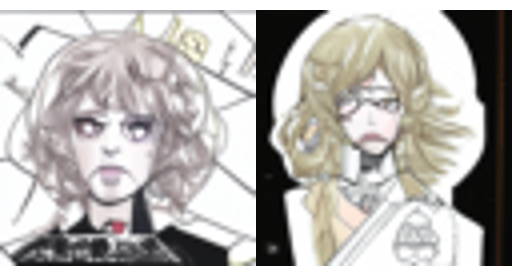

Button(description='Download', style=ButtonStyle())

Done


In [23]:
#@title
import io
import torchvision.transforms as T
from PIL import Image
from IPython.display import display, clear_output
from ipywidgets import interact
try:
  from google.colab import files
  can_download = True
except ImportError:
  can_download = False

file_input = widgets.FileUpload(
    multiple=False
)

text_input = widgets.Textarea(
    placeholder='Prompts separated by new lines... An image can also be uploaded from the file upload button below to go with the prompts...',
    value=str(current_state["text_input"]),
    disabled=False,
    continuous_update=True,
    layout={'width': 'auto'},
    rows=10
)
textbox_box = widgets.VBox([text_input, file_input], layout={'border': '2px solid grey'})

prior_label = widgets.HTML(value="<b>Prior Options:</b> Set how many sample to take from the prior and what conditioning scale to use.")
text_repeat = widgets.IntSlider(
    value=int(current_state["text_repeat"]),
    min=1,
    max=10,
    step=1,
    description='Text/Image Input Repeat',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width="100%")
)

prior_conditioning = widgets.FloatSlider(
    value=float(current_state["prior_conditioning"]),
    min=0.0,
    max=10.0,
    step=0.1,
    description='Prior Cond Scale',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width="100%")
)
prior_options_box = widgets.VBox([prior_label, text_repeat, prior_conditioning], layout=widgets.Layout(border="2px solid grey", padding="5px 10px", flex="1 0 auto"))

decoder_label = widgets.HTML(value="<b>Decoder Options:</b> Set how many sample to take from the decoder and what conditioning scale to use.")
img_repeat = widgets.IntSlider(
    value=int(current_state["img_repeat"]),
    min=1,
    max=10,
    step=1,
    description='Img Repeat',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width="100%")
)

decoder_conditioning = widgets.FloatSlider(
    value=float(current_state["decoder_conditioning"]),
    min=0.0,
    max=10.0,
    step=0.1,
    description='Decoder Cond Scale',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width="100%")
)
decoder_options_box = widgets.VBox([decoder_label, img_repeat, decoder_conditioning], layout=widgets.Layout(border="2px solid grey", padding="5px 10px", flex="1 0 auto"))
main_options_box = widgets.HBox([prior_options_box, decoder_options_box], layout=widgets.Layout(width="100%"))

include_prompt_checkbox = widgets.Checkbox(
    value=bool(current_state["include_prompt_checkbox"]),
    description='Show prompt in output image',
    disabled=False,
    indent=False
)

button = widgets.Button(
    description="Start"
)
final_options_box = widgets.HBox([include_prompt_checkbox, button], layout=widgets.Layout(justify_content="space-between", border="2px solid grey", padding="10px 30px"))

main_layout = widgets.VBox([textbox_box, main_options_box, final_options_box])

def get_prompts():
  return list(filter(lambda v: len(v) > 0, text_input.value.split("\n")))

def f(text_input, text_repeat, prior_conditioning, img_repeat, decoder_conditioning, include_prompt_checkbox):
  prompts = get_prompts()
  total_images = len(prompts) * text_repeat * img_repeat
  global current_text
  current_text = text_input

  global current_state
  current_state = {
      "text_input": text_input,
      "text_repeat": text_repeat,
      "prior_conditioning": prior_conditioning,
      "img_repeat": img_repeat,
      "decoder_conditioning": decoder_conditioning,
      "include_prompt_checkbox": include_prompt_checkbox
  }

  output_strings = []
  output_strings.append(f"Total output images: {total_images}")
  output_strings.append("")
  output_strings.extend([f"Prompt {index}: {prompt}" for index, prompt in enumerate(prompts)])
  output_strings.append("")
  output_strings.append("Including prompt text in output image" if include_prompt_checkbox else "Not including prompt text in output image")
  output_strings.append(f"Prior Conditioning Scale: {prior_conditioning}")
  output_strings.append(f"Decoder Conditioning Scale: {decoder_conditioning}")
  print('\n'.join(output_strings))

out = widgets.interactive_output(f, {'text_input': text_input, 'text_repeat': text_repeat, 'prior_conditioning': prior_conditioning, 'img_repeat': img_repeat, 'decoder_conditioning': decoder_conditioning, 'include_prompt_checkbox': include_prompt_checkbox})

display(main_layout, out)

def on_start(_, recall_embeddings=False, recall_images=False):
  clear_output()
  display(main_layout, out)
  prompts = get_prompts()
  prior_cond_scale = prior_conditioning.value
  decoder_cond_scale = decoder_conditioning.value
  text_rep = text_repeat.value
  img_rep = img_repeat.value
  include_prompt = include_prompt_checkbox.value
  
  prior_text_input = []
  for prompt in prompts:
    for _ in range(text_rep):
      prior_text_input.append(prompt)
  
  tokens = tokenizer.tokenize(prior_text_input).to(device)
  if recall_embeddings:
    print("Loading embeddings")
    image_embed = np.load('img_emb_prior.npy')
  else:
    if file_input.value is None:
      print("Running prior")
      with torch.no_grad():
        image_embed = diffusion_prior.sample(tokens, cond_scale = prior_cond_scale).cpu().numpy()
      np.save('img_emb_prior.npy', image_embed)
    else:
      print(f"Skipping prior -- using Prior Text Repeat as batch size of {text_rep}")
      for name, file_info in file_input.value.items():
        image_pil = Image.open(io.BytesIO(file_info['content']))
        image_tensor = T.ToTensor()(image_pil).unsqueeze_(0).to(device)
        unbatched_image_embed, _ = clip.embed_image(image_tensor)
        image_embed = torch.zeros(text_rep, 768) # TODO: replace with length returned by CLIP instead of hardcoding to 768
        for i in range(len(image_embed)):
          image_embed[i] = unbatched_image_embed
        image_embed = image_embed.cpu().numpy()
      np.save('img_emb_prior.npy', image_embed)

  embeddings = np.repeat(image_embed, img_rep, axis=0)
  embeddings = torch.from_numpy(embeddings).float().to(device)

  if recall_images:
    print("Loading images")
    np_images = np.load('images_decoder.npy')
  else:
    print("Running decoder")
    with torch.no_grad():
      if decoder_text_conditioned:
        print("Generating clip embeddings")
        _, text_encoding, text_mask = clip.embed_text(tokens)
        images = decoder.sample(embeddings, text_encodings = text_encoding, text_mask = text_mask, cond_scale = decoder_cond_scale)
      else:
        print("Not generating clip embeddings")
        images = decoder.sample(embeddings, text = None, cond_scale = decoder_cond_scale)
    np_images = images.cpu().permute(0, 2, 3, 1)
    np.save('images_decoder.npy', np_images)

  if not prompts:
    prompts = [' ']
  img_map = map_images(np_images, text_rep, img_rep, prompts, upscale=4)
  for index, (prompt, imgs) in enumerate(img_map.items()):
    img = format_image_grid(imgs)
    if include_prompt:
      img = format_prompt_image(prompt, img, font_size=20, horizontal_padding=5, vertical_padding=5)
    display(img)
    if can_download:
      download_button = widgets.Button(
        description="Download"
      )
      display(download_button)
      download_button.on_click(lambda b: files.download(f"./output/example_{index}.png"))
    os.makedirs("./output", exist_ok=True)
    img.save(f"./output/example_{index}.png")
  
  print('Done')

button.on_click(on_start)

### Rerank Test

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 250 image embeddings
[0.2354239, 0.23872441, 0.24527892, 0.24562277, 0.2498377] 0.2354239 0.2498377
[0.21531269, 0.2155003, 0.21564046, 0.21874422, 0.22868255] 0.21531269 0.22868255
[0.22410016, 0.22410926, 0.2297209, 0.23635748, 0.239931] 0.22410016 0.239931
[0.24337083, 0.24406064, 0.24546558, 0.24880663, 0.25361258] 0.24337083 0.25361258
[0.21674016, 0.21773818, 0.21893652, 0.22169295, 0.22312428] 0.21674016 0.22312428
After reranking there are 25 image embeddings
Generating clip embeddings


0it [00:00, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

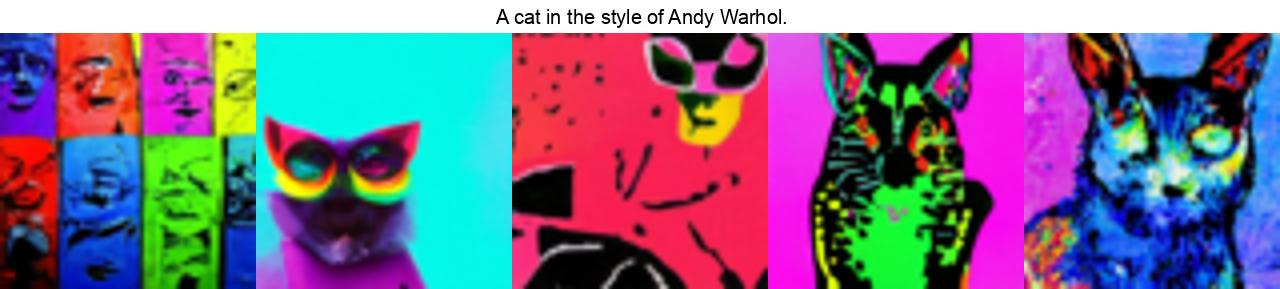

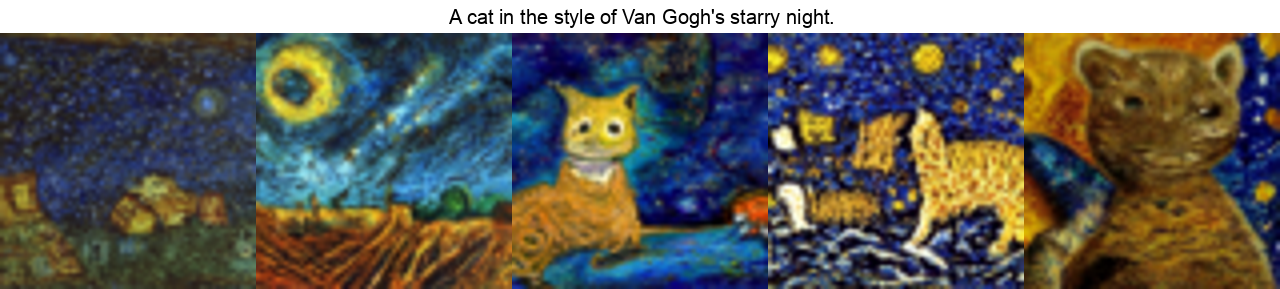

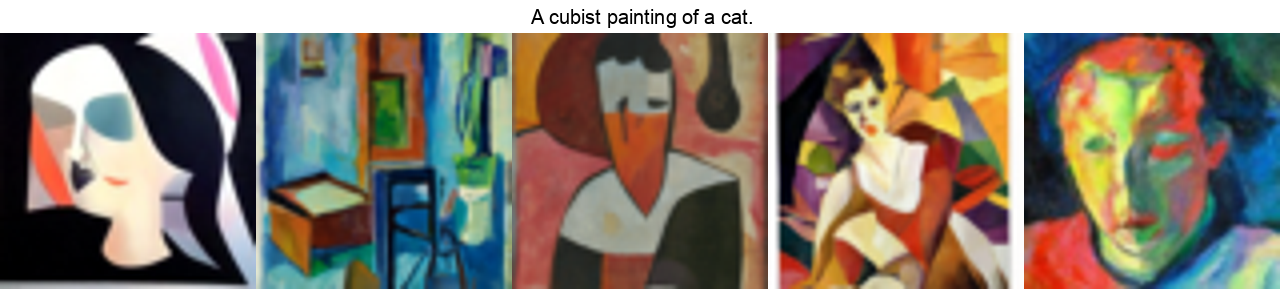

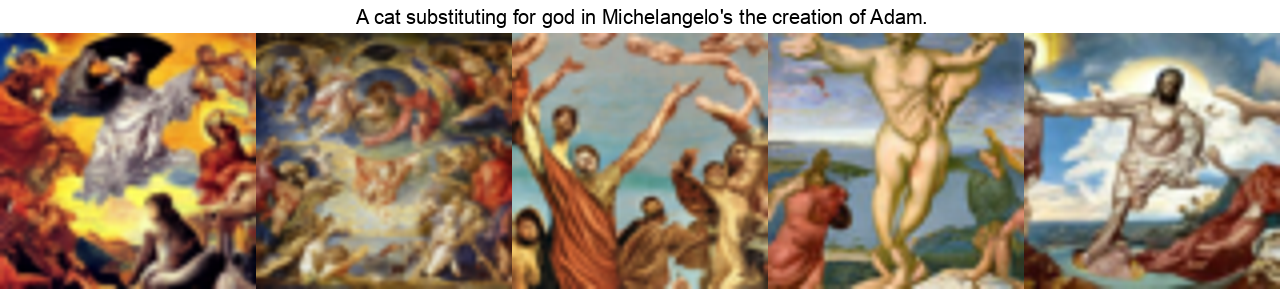

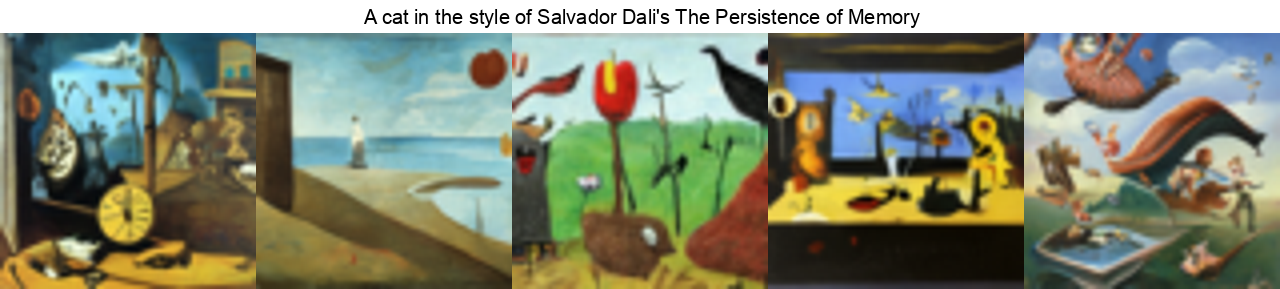

In [ ]:
#@title
"""
Here we take the prompt, generate n number of embeddings and rerank them by cosine similarity to the text embedding, 
then take a linspace of N and sample the decoder with those embeddings to see the variation in the performance of the prior
"""
def rerank_and_sample(image_embeddings, text_embedding, samples=None, strategy="top"):
  if samples is None:
    samples = len(image_embeddings)
  
  def similarity(image_embedding, text_embedding):
    image_embedding = image_embedding / np.linalg.norm(image_embedding)
    text_embedding = text_embedding / np.linalg.norm(text_embedding)
    return np.inner(image_embedding, text_embedding)

  reranked = sorted(list(image_embeddings), key=lambda img_emb: similarity(img_emb, text_embedding))
  if strategy == "top":
    sampled_embeddings = np.array(reranked[-samples:])
  elif strategy == "even":
    sample_indices = np.linspace(0, len(reranked) - 1, num=samples, dtype=int)
    sampled_embeddings = np.array([reranked[i] for i in sample_indices])
  rankings = [similarity(emb, text_embedding) for emb in sampled_embeddings]
  print(rankings, rankings[0], rankings[-1])
  return sampled_embeddings

def rerank_test(num_samples, num_trials):
  prompts = get_prompts()
  prior_cond_scale = prior_conditioning.value
  decoder_cond_scale = decoder_conditioning.value
  text_rep = text_repeat.value
  img_rep = img_repeat.value
  include_prompt = include_prompt_checkbox.value

  prompt_tokens = tokenizer.tokenize(prompts).to(device)
  prompt_embeddings, prompt_encoding, prompt_mask = clip.embed_text(prompt_tokens)
  prompt_embeddings = prompt_embeddings.cpu().numpy()

  prior_prompts = []
  for prompt in prompts:
    for _ in range(num_trials):
      prior_prompts.append(prompt)

  sample_prompts = []
  for prompt in prompts:
    for _ in range(num_samples):
      sample_prompts.append(prompt)

  tokens = tokenizer.tokenize(prior_prompts).to(device)
  with torch.no_grad():
      image_embed = diffusion_prior.sample(tokens, cond_scale = prior_cond_scale).cpu().numpy()
  print(f"Generated {len(image_embed)} image embeddings")

  image_embed = np.split(image_embed, len(prompts))
  reranked_embeddings = []
  for i, embedding_set in enumerate(image_embed):
    reranked_embeddings.append(rerank_and_sample(embedding_set, prompt_embeddings[i], samples=num_samples))
  
  sampled_embedding_array = np.concatenate(reranked_embeddings)
  print(f"After reranking there are {len(sampled_embedding_array)} image embeddings")
  sampled_embedding_tensor = torch.from_numpy(sampled_embedding_array).to(device)

  sample_tokens = tokenizer.tokenize(sample_prompts).to(device)
  with torch.no_grad():
    if decoder_text_conditioned:
      print("Generating clip embeddings")
      _, text_encoding, text_mask = clip.embed_text(sample_tokens)
      images = decoder.sample(sampled_embedding_tensor, text_encodings = text_encoding, text_mask = text_mask, cond_scale = decoder_cond_scale)
    else:
      print("Not generating clip embeddings")
      images = decoder.sample(sampled_embedding_tensor, text = None, cond_scale = decoder_cond_scale)
  np_images = images.cpu().permute(0, 2, 3, 1)
  img_map = map_images(np_images, num_samples, 1, prompts, upscale=4)
  for index, (prompt, imgs) in enumerate(img_map.items()):
    img = format_image_grid(imgs)
    if include_prompt:
      img = format_prompt_image(prompt, img, font_size=20, horizontal_padding=5, vertical_padding=5)
    display(img)
    if can_download:
      download_button = widgets.Button(
        description="Download"
      )
      display(download_button)
      download_button.on_click(lambda b: files.download(f"./output/example_{index}.png"))
    os.makedirs("./reranked_output", exist_ok=True)
    img.save(f"./reranked_output/example_{index}.png")

rerank_test(5, 50)